# Task 1.2: missing river data imputation 


In [2]:
# Install required packages (only needed once, safe to re-run)
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "matplotlib", "openpyxl", "pandas", "numpy"])

# Load ALL river files
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from openpyxl import load_workbook
import warnings
warnings.filterwarnings("ignore")

# Path to the folder with all river Excel files (your local path)
DATA_DIR = "/Users/ezgi/Desktop/missing data /Donnees Hydro et Meteo Mensuelles_IGEBU"

# Find all river files
river_files = sorted(f for f in os.listdir(DATA_DIR) if "Riviere" in f and f.endswith(".xlsx"))
print(f"Found {len(river_files)} river files:")
for f in river_files:
    print(f"  - {f}")


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip


Found 11 river files:
  - Niveaux d'eau de la Riviere Buzimba.xlsx
  - Niveaux d'eau de la Riviere Dama.xlsx
  - Niveaux d'eau de la Riviere Jiji.xlsx
  - Niveaux d'eau de la Riviere Kaburantwa.xlsx
  - Niveaux d'eau de la Riviere Mpanda.xlsx
  - Niveaux d'eau de la Riviere Mulembwe.xlsx
  - Niveaux d'eau de la Riviere Mutimbuzi.xlsx
  - Niveaux d'eau de la Riviere Nyakagunda.xlsx
  - Niveaux d'eau de la Riviere Nyamagana.xlsx
  - Niveaux d'eau de la Riviere Nyengwe.xlsx
  - Niveaux d'eau de la Riviere RUSIZI.xlsx


In [3]:
# Data preparation: load all rivers, auto-detect headers, build complete monthly grids

# Helper: auto-detect header row (each file has it on a different row)
def find_header_row(filepath):
    wb = load_workbook(filepath, data_only=True)
    ws = wb.active
    for i, row in enumerate(ws.iter_rows(max_row=10, values_only=True)):
        vals = [str(v).strip().lower() if v else "" for v in row]
        if "year" in vals or "yy" in vals:
            wb.close()
            return i
    wb.close()
    return 0

# Helper: standardize column names across different files
def normalize_columns(df):
    col_map = {}
    for c in df.columns:
        cl = str(c).strip().lower()
        if cl in ("station_name", "name"):  col_map[c] = "Station_Name"
        elif cl == "stationid":             col_map[c] = "StationID"
        elif cl == "lat":                   col_map[c] = "Lat"
        elif cl == "lon":                   col_map[c] = "Lon"
        elif cl in ("elev", "alt"):         col_map[c] = "Elev"
        elif cl in ("year", "yy"):          col_map[c] = "Year"
        elif cl in ("month", "mm"):         col_map[c] = "Month"
        elif "haut" in cl and "moy" in cl:  col_map[c] = "haut_moy"
    return df.rename(columns=col_map)

# Load and prepare ALL rivers into a dictionary
rivers = {}

for fname in river_files:
    path = os.path.join(DATA_DIR, fname)
    river_name = fname.replace("Niveaux d'eau de la Riviere ", "").replace(".xlsx", "")

    # Read with auto-detected header and normalize columns
    header_row = find_header_row(path)
    df = pd.read_excel(path, header=header_row)
    df = normalize_columns(df)
    if "StationID" in df.columns:
        df = df.drop(columns=["StationID"])

    # Keep only the columns we need
    df = df[["Station_Name", "Lat", "Lon", "Elev", "Year", "Month", "haut_moy"]]

    # Clean: drop empty rows, ensure Year/Month are valid integers
    df = df.dropna(how="all").reset_index(drop=True)
    df = df.dropna(subset=["Year", "Month"]).reset_index(drop=True)
    df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
    df["Month"] = pd.to_numeric(df["Month"], errors="coerce")
    df = df.dropna(subset=["Year", "Month"]).reset_index(drop=True)
    df["Year"] = df["Year"].astype(int)
    df["Month"] = df["Month"].astype(int)

    # Create Date column and build a complete monthly grid
    df["Date"] = pd.to_datetime(df[["Year", "Month"]].assign(Day=1))
    df = df.sort_values("Date").drop_duplicates(subset=["Date"]).reset_index(drop=True)

    # Fill station metadata
    for col in ["Station_Name", "Lat", "Lon", "Elev"]:
        df[col] = df[col].ffill().bfill()

    station_info = {c: df[c].iloc[0] for c in ["Station_Name", "Lat", "Lon", "Elev"]}

    # Reindex to complete monthly grid (gaps become NaN)
    full_range = pd.date_range(start=df["Date"].min(), end=df["Date"].max(), freq="MS")
    df = df.set_index("Date").reindex(full_range)
    df.index.name = "Date"
    for c, v in station_info.items():
        df[c] = v
    df["Year"] = df.index.year
    df["Month"] = df.index.month

    rivers[river_name] = df

print(f"Loaded {len(rivers)} rivers successfully!\n")
for name, df in rivers.items():
    n_miss = df["haut_moy"].isna().sum()
    print(f"  {name:20s} | {len(df):4d} months | {n_miss:3d} missing ({100*n_miss/len(df):.1f}%)")



Loaded 11 rivers successfully!

  Buzimba              |  396 months |  52 missing (13.1%)
  Dama                 |  417 months |   3 missing (0.7%)
  Jiji                 |  528 months |   5 missing (0.9%)
  Kaburantwa           |  509 months | 170 missing (33.4%)
  Mpanda               |  191 months |  20 missing (10.5%)
  Mulembwe             |  521 months |  46 missing (8.8%)
  Mutimbuzi            |  431 months | 301 missing (69.8%)
  Nyakagunda           |  528 months | 228 missing (43.2%)
  Nyamagana            |  528 months | 192 missing (36.4%)
  Nyengwe              |  504 months | 252 missing (50.0%)
  RUSIZI               |  528 months | 167 missing (31.6%)


In [ ]:
# Correlation analysis moved to a separate notebook:
# corelation.ipynb
#
# Keep this notebook focused on loading, imputing, and visualizing missing data.

In [4]:
# Show missing data details for each river
for name, df in rivers.items():
    missing = df[df["haut_moy"].isna()]
    if len(missing) > 0:
        dates = [d.strftime("%Y-%m") for d in missing.index]
        print(f"[{name}] — {len(missing)} missing months:")
        print(f"  {dates}\n")
    else:
        print(f"[{name}] — No missing values\n")

[Buzimba] — 52 missing months:
  ['1982-09', '1982-10', '1982-11', '1982-12', '1983-01', '1983-02', '1983-03', '1983-04', '1983-05', '1983-06', '1983-07', '1983-08', '1983-09', '1983-10', '1983-11', '1983-12', '1984-01', '2008-05', '2008-06', '2008-07', '2008-08', '2008-09', '2008-10', '2010-03', '2010-04', '2010-05', '2010-06', '2010-07', '2010-08', '2010-09', '2010-10', '2010-11', '2010-12', '2011-01', '2011-02', '2011-03', '2011-04', '2011-05', '2011-06', '2011-07', '2011-08', '2011-09', '2011-10', '2011-11', '2011-12', '2012-01', '2012-02', '2012-03', '2012-04', '2012-05', '2012-06', '2012-07']

[Dama] — 3 missing months:
  ['2008-12', '2015-11', '2015-12']

[Jiji] — 5 missing months:
  ['1983-05', '1986-11', '1998-03', '2024-10', '2024-11']

[Kaburantwa] — 170 missing months:
  ['1995-04', '1995-05', '1995-06', '1995-07', '1995-08', '1995-09', '1995-10', '1995-11', '1995-12', '1996-01', '1996-02', '1996-03', '1996-04', '1996-05', '1996-06', '1996-07', '1996-08', '1996-09', '1996-1

In [ ]:
# BEFORE imputation — plot each river's water level with gaps visible

# Rivers with missing data (skip RUSIZI which has 0 missing)
rivers_with_missing = {k: v for k, v in rivers.items() if v["haut_moy"].isna().sum() > 0}
n_rivers = len(rivers_with_missing)

fig, axes = plt.subplots(n_rivers, 1, figsize=(16, 4 * n_rivers), sharex=False)
if n_rivers == 1:
    axes = [axes]

for ax, (name, df) in zip(axes, rivers_with_missing.items()):
    n_miss = df["haut_moy"].isna().sum()

    # Plot the existing data (gaps will show as breaks in the line)
    ax.plot(df.index, df["haut_moy"], color="steelblue", linewidth=0.8, label="Observed")

    # Mark missing periods with red vertical spans
    missing_idx = df.index[df["haut_moy"].isna()]
    for d in missing_idx:
        ax.axvline(x=d, color="red", alpha=0.3, linewidth=0.8)

    ax.set_title(f"{name}  —  {n_miss} missing months (red = missing)", fontsize=12, fontweight="bold")
    ax.set_ylabel("Water Level (m)")
    ax.legend(loc="upper right")
    ax.grid(True, alpha=0.3)

fig.suptitle("BEFORE Imputation — River Water Levels with Missing Data", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

In [5]:
# Imputation: use each river's own past values (same-month climatological mean)
#
# For each missing month, we compute the average of that SAME calendar month
# across all other years. Example: missing April 2011 → mean of all other Aprils.
# This preserves the seasonal pattern of the river.

rivers_imputed = {}

for name, df in rivers.items():
    df = df.copy()
    n_before = df["haut_moy"].isna().sum()

    if n_before == 0:
        df["haut_moy_imputed"] = df["haut_moy"].copy()
        rivers_imputed[name] = df
        print(f"[{name}] — No missing values, nothing to impute.")
        continue

    # Step 1: Compute the mean water level for each calendar month (1–12)
    monthly_means = df.groupby("Month")["haut_moy"].mean()

    # Step 2: Fill each missing value with its calendar month's mean
    df["haut_moy_imputed"] = df["haut_moy"].copy()
    for idx in df.index[df["haut_moy_imputed"].isna()]:
        month = idx.month
        df.loc[idx, "haut_moy_imputed"] = monthly_means.get(month, np.nan)

    # Step 3: Fallback — linear interpolation for any remaining NaN
    remaining = df["haut_moy_imputed"].isna().sum()
    if remaining > 0:
        df["haut_moy_imputed"] = df["haut_moy_imputed"].interpolate(method="linear")

    n_after = df["haut_moy_imputed"].isna().sum()
    rivers_imputed[name] = df
    print(f"[{name}] — {n_before} missing → {n_after} missing after imputation ✓")

print(f"\nAll {len(rivers_imputed)} rivers imputed!")

[Buzimba] — 52 missing → 0 missing after imputation ✓
[Dama] — 3 missing → 0 missing after imputation ✓
[Jiji] — 5 missing → 0 missing after imputation ✓
[Kaburantwa] — 170 missing → 0 missing after imputation ✓
[Mpanda] — 20 missing → 0 missing after imputation ✓
[Mulembwe] — 46 missing → 0 missing after imputation ✓
[Mutimbuzi] — 301 missing → 0 missing after imputation ✓
[Nyakagunda] — 228 missing → 0 missing after imputation ✓
[Nyamagana] — 192 missing → 0 missing after imputation ✓
[Nyengwe] — 252 missing → 0 missing after imputation ✓
[RUSIZI] — 167 missing → 0 missing after imputation ✓

All 11 rivers imputed!


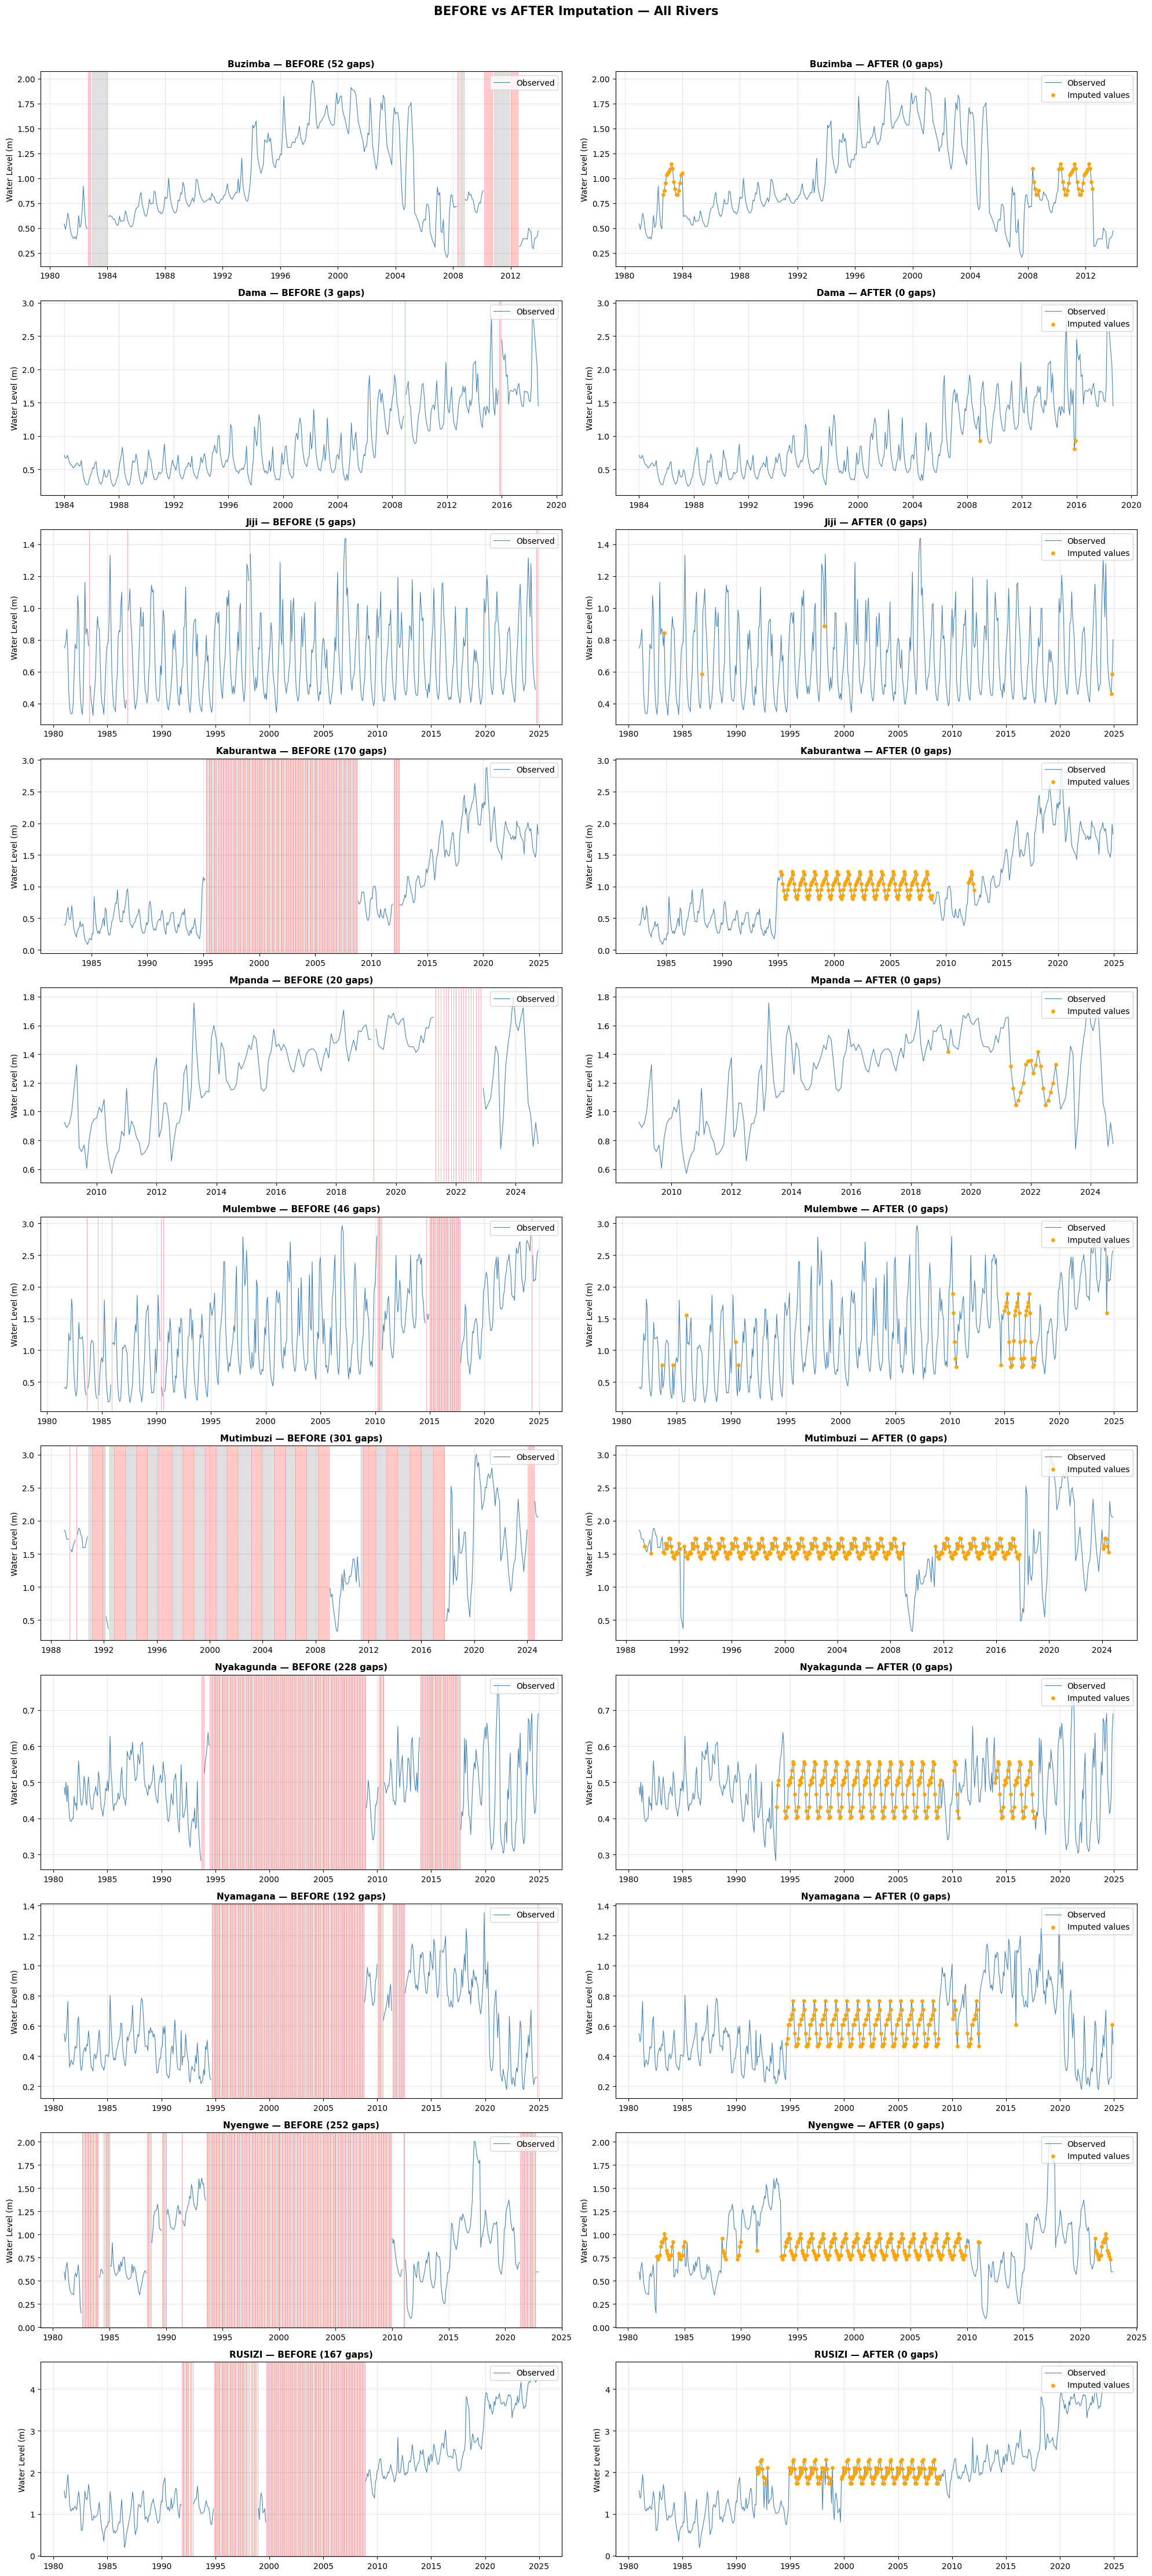

In [7]:
# COMPARISON: Before vs After imputation — side by side for each river

# Only plot rivers that had missing data
rivers_with_missing = {k: v for k, v in rivers.items() if v["haut_moy"].isna().sum() > 0}
rivers_to_plot = {k: rivers_imputed[k] for k in rivers_with_missing}

n = len(rivers_to_plot)
fig, axes = plt.subplots(n, 2, figsize=(20, 4 * n))
if n == 1:
    axes = axes.reshape(1, -1)

for i, (name, df) in enumerate(rivers_to_plot.items()):
    ax_before = axes[i, 0]
    ax_after = axes[i, 1]
    n_miss_orig = rivers[name]["haut_moy"].isna().sum()

    # --- LEFT: BEFORE imputation ---
    ax_before.plot(df.index, df["haut_moy"], color="steelblue", linewidth=0.8, label="Observed")
    missing_idx = df.index[df["haut_moy"].isna()]
    for d in missing_idx:
        ax_before.axvline(x=d, color="red", alpha=0.3, linewidth=0.8)
    ax_before.set_title(f"{name} — BEFORE ({n_miss_orig} gaps)", fontsize=11, fontweight="bold")
    ax_before.set_ylabel("Water Level (m)")
    ax_before.grid(True, alpha=0.3)
    ax_before.legend(loc="upper right")

    # --- RIGHT: AFTER imputation ---
    ax_after.plot(df.index, df["haut_moy_imputed"], color="steelblue", linewidth=0.8, label="Observed")
    # Highlight the imputed points in orange
    imputed_mask = df["haut_moy"].isna()
    ax_after.scatter(df.index[imputed_mask], df.loc[imputed_mask, "haut_moy_imputed"],
                     color="orange", s=15, zorder=5, label="Imputed values")
    ax_after.set_title(f"{name} — AFTER (0 gaps)", fontsize=11, fontweight="bold")
    ax_after.set_ylabel("Water Level (m)")
    ax_after.grid(True, alpha=0.3)
    ax_after.legend(loc="upper right")

fig.suptitle("BEFORE vs AFTER Imputation — All Rivers", fontsize=15, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

In [8]:
# Summary table: before vs after imputation for all rivers
summary = []
for name in rivers:
    n_total = len(rivers[name])
    n_before = rivers[name]["haut_moy"].isna().sum()
    n_after = rivers_imputed[name]["haut_moy_imputed"].isna().sum()
    period = f"{rivers[name].index.min().strftime('%Y-%m')} to {rivers[name].index.max().strftime('%Y-%m')}"
    summary.append({
        "River": name,
        "Period": period,
        "Total Months": n_total,
        "Missing Before": n_before,
        "Missing After": n_after,
        "% Filled": f"{100*(n_before - n_after)/max(n_before, 1):.0f}%"
    })

summary_df = pd.DataFrame(summary)
print("Imputation Summary — Same-Month Climatological Mean")
print("=" * 85)
print(summary_df.to_string(index=False))
print(f"\nMethod: Each missing month is filled with the average of the same calendar month")
print(f"        across all other years of the same river (preserves seasonal patterns).")

Imputation Summary — Same-Month Climatological Mean
     River             Period  Total Months  Missing Before  Missing After % Filled
   Buzimba 1981-01 to 2013-12           396              52              0     100%
      Dama 1984-01 to 2018-09           417               3              0     100%
      Jiji 1981-01 to 2024-12           528               5              0     100%
Kaburantwa 1982-08 to 2024-12           509             170              0     100%
    Mpanda 2008-12 to 2024-10           191              20              0     100%
  Mulembwe 1981-08 to 2024-12           521              46              0     100%
 Mutimbuzi 1989-01 to 2024-11           431             301              0     100%
Nyakagunda 1981-01 to 2024-12           528             228              0     100%
 Nyamagana 1981-01 to 2024-12           528             192              0     100%
   Nyengwe 1981-01 to 2022-12           504             252              0     100%
    RUSIZI 1981-01 to 20